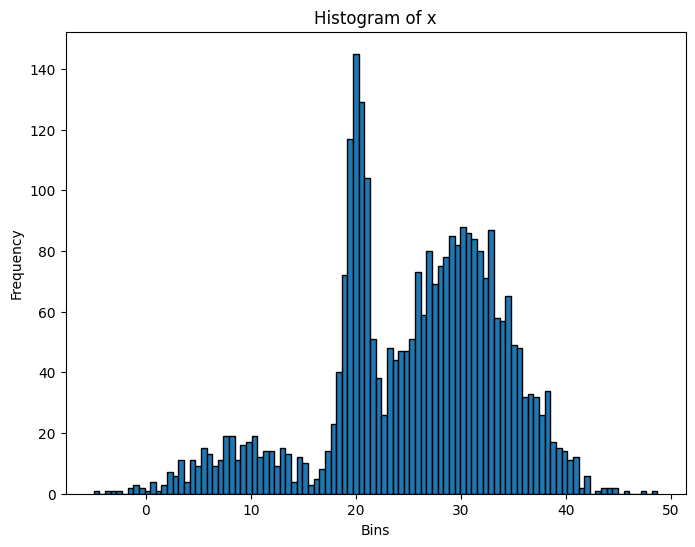

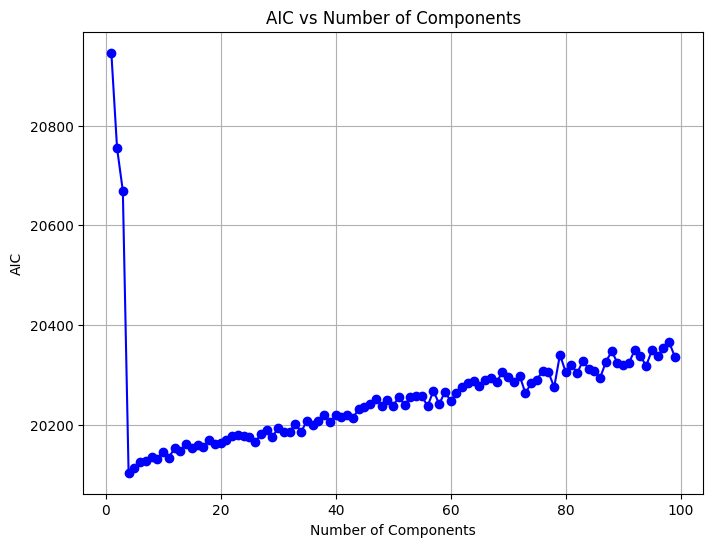

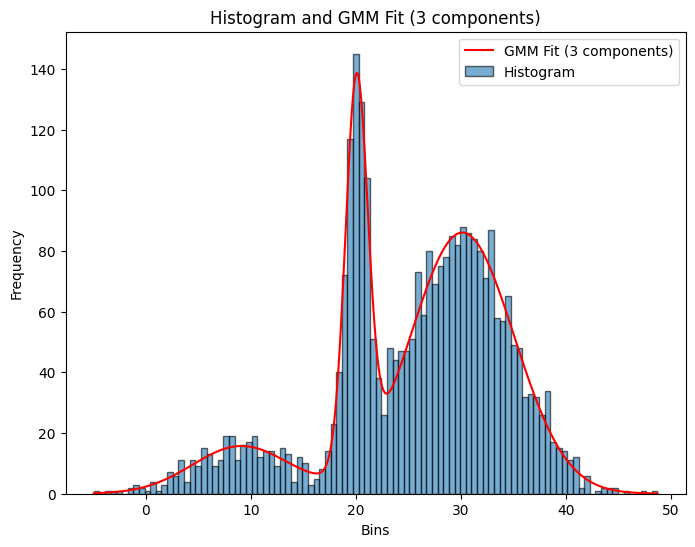

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
   
def load_file(file_path):
    """Load the content of a text file or a .npy file."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File {file_path} does not exist.")
    
    if file_path.endswith('.npy'):
        return np.load(file_path, allow_pickle=True)

x = load_file('/Users/albertozanelli/Desktop/astrostatistics_bicocca_2025/solutions/formationchannels.npy')

# Compute the histogram
hist, bin_edges = np.histogram(x, bins=100)

# Plot the histogram
plt.figure(figsize=(8, 6))
plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), edgecolor="black", align="edge")
plt.xlabel('Bins')
plt.ylabel('Frequency')
plt.title('Histogram of x')
plt.show()

list_AIC = []   
for i in range(1, 100):
    mod = GaussianMixture(n_components=i)
    fit = mod.fit(x)
    aic = mod.aic(x)
    list_AIC.append(aic)


# Plot the AIC value for each model
plt.figure(figsize=(8, 6))
plt.plot(range(1, 100), list_AIC, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Components')
plt.ylabel('AIC')
plt.title('AIC vs Number of Components')
plt.grid(True)
plt.show()

# Fit the Gaussian Mixture Model with 3 components
gmm_3 = GaussianMixture(n_components=3)
gmm_3.fit(x)

# Generate points for plotting the fit
x_values = np.linspace(bin_edges[0], bin_edges[-1], 1000).reshape(-1, 1)
log_density = gmm_3.score_samples(x_values)
density = np.exp(log_density)

# Plot the histogram and the fitted GMM
plt.figure(figsize=(8, 6))
plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), edgecolor="black", align="edge", alpha=0.6, label='Histogram')
plt.plot(x_values, density * len(x) * np.diff(bin_edges)[0], color='red', label='GMM Fit (3 components)')
plt.xlabel('Bins')
plt.ylabel('Frequency')
plt.title('Histogram and GMM Fit (3 components)')
plt.legend()
plt.show()


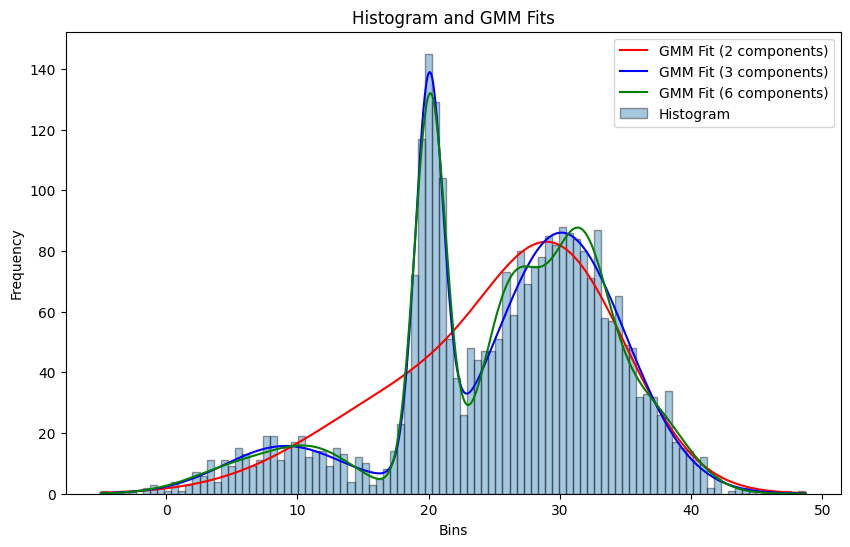

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram
ax.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), edgecolor="black", align="edge", alpha=0.4, label='Histogram')

colors = ['red', 'blue', 'green']
n_components_list = [2, 3, 6]

for n, color in zip(n_components_list, colors):
    gmm = GaussianMixture(n_components=n)
    gmm.fit(x)
    log_density = gmm.score_samples(x_values)
    density = np.exp(log_density)
    ax.plot(x_values, density * len(x) * np.diff(bin_edges)[0], color=color, label=f'GMM Fit ({n} components)')

ax.set_xlabel('Bins')
ax.set_ylabel('Frequency')
ax.set_title('Histogram and GMM Fits')
ax.legend()
plt.show()

The **Akaike Information Criterion (AIC)** was used to determine the optimal number of Gaussian components. The AIC plot shows a decreasing trend that **stabilizes around 3 components**, indicating that adding more components beyond this point does not significantly improve the model fit while increasing complexity.

The Gaussian Mixture Model with **3 components** provides a good fit to the data, capturing the main modes of the distribution. The comparison across different numbers of components (2, 3, and 6) shows:

- **2 components**: Underfits the data, missing some secondary peaks
- **3 components**: Balances model complexity and goodness of fit
- **6 components**: Overfits, introducing spurious substructures not supported by the data